nous allons visualiser l'espace latent à l'aide de l'ACP en suivant ces étapes :

-Prétraitement des données : Nous normalisons l'ensemble de données MNIST et aplatissons les images pour l'auto-encodeur.

-Architecture d'un auto-encodeur : L'auto-encodeur se compose d'un encodeur qui compresse les données dans un espace latent et d'un décodeur qui reconstruit les données originales à partir de cet espace latent.

-Entraînement : Nous entraînons l'autoencodeur sur l'ensemble de données MNIST, ce qui aide le modèle à apprendre des représentations significatives dans l'espace latent.

-Réduction de dimensionnalité : Nous utilisons l’ACP pour réduire l’espace latent à 2D à des fins de visualisation. Vous pouvez également utiliser t-SNE pour une séparation visuelle potentiellement meilleure.

-Représentation graphique : Nous utilisons Matplotlib pour créer des nuages ​​de points représentant les espaces latents, ce qui permet de comprendre visuellement comment le modèle organise les données.

# Importer les bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

2026-01-14 08:20:48.108558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768378848.318351      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768378848.377838      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768378848.868779      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768378848.868825      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768378848.868829      17 computation_placer.cc:177] computation placer alr

In [2]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images from (28, 28) to (784,)
x_train = x_train.reshape((x_train.shape[0], 28*28))
x_test = x_test.reshape((x_test.shape[0], 28*28))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Define Autoencoder Architecture

In [3]:
input_dim = x_train.shape[1]  # 784
encoding_dim = 32  # Size of latent space

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Complete Autoencoder model
autoencoder = Model(input_layer, decoded)

# Separate Encoder model for latent space extraction
encoder = Model(input_layer, encoded)

2026-01-14 08:21:04.662260: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Compile and Train the Autoencoder

In [4]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train for 50 epochs with batch size 256
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3878 - val_loss: 0.1868
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1771 - val_loss: 0.1529
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1492 - val_loss: 0.1340
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1316 - val_loss: 0.1213
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1204 - val_loss: 0.1129
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1129 - val_loss: 0.1075
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1076 - val_loss: 0.1033
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1037 - val_loss: 0.1000
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1007 - val_loss: 0.0977
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0984 - val_loss: 0.0960
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0971 - val_loss: 0.0948
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

# Extract Latent Space Representations

In [5]:
latent_space_train = encoder.predict(x_train)
latent_space_test = encoder.predict(x_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


# Apply PCA for Dimensionality Reduction

In [6]:
pca = PCA(n_components=2)

latent_space_train_pca = pca.fit_transform(latent_space_train)
latent_space_test_pca = pca.transform(latent_space_test)

# Visualize the Latent Space

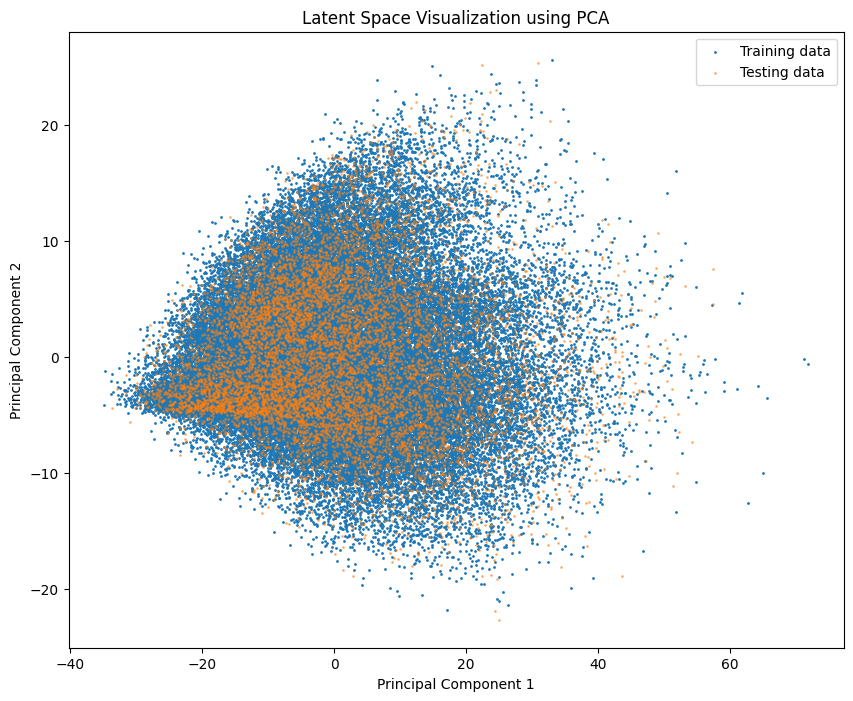

In [7]:
plt.figure(figsize=(10, 8))
plt.scatter(latent_space_train_pca[:, 0], latent_space_train_pca[:, 1], s=1, label='Training data')
plt.scatter(latent_space_test_pca[:, 0], latent_space_test_pca[:, 1], s=1, label='Testing data', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Latent Space Visualization using PCA')
plt.legend()
plt.show()

# Applications of Latent Space in Deep Learning
-Data Compression: Latent space representations can be used for compressing data, making storage and transmission more efficient.

-Anomaly Detection: By analyzing the latent space, models can identify anomalies or outliers that deviate significantly from the learned distribution.

-Data Generation: Latent space allows for the generation of new data samples, which is valuable in creative fields such as art, music and synthetic data creation.

-Transfer Learning: Latent space representations learned from one domain can be transferred to other domains, facilitating knowledge transfer and improving model performance on new tasks.